# Crawling & Analisis Data Polutan Udara di Kabupaten Madiun

Nama : Magdalena Jovita Hatuopar

NIM : 240411100078

Mata Kuliah : Pengantar Sains Data (PSD)

## Gambaran Wilayah Analisa

Kabupaten Madiun terletak di bagian barat Provinsi Jawa Timur, mengelilingi Kota Madiun dan berbatasan dengan Kabupaten Ngawi, Kabupaten Nganjuk, Kabupaten Magetan, serta Kabupaten Ponorogo. Wilayah ini masih didominasi oleh **sektor pertanian**, khususnya persawahan padi dan perkebunan tebu, yang tersebar luas di dataran rendahnya. Di sisi lain, dalam satu dekade terakhir Pemerintah Kabupaten Madiun mendorong pertumbuhan **kawasan industri baru** terutama di Kecamatan Balerejo dan Pilangkenceng, memanfaatkan lahan yang luas serta kedekatan dengan akses jalan tol Ngawi–Kertosono. Kabupaten Madiun juga menjadi lokasi **Pangkalan Udara (Lanud) Iswahyudi** di Kecamatan Maospati, serta dilalui jalur distribusi darat lintas Jawa (Solo–Madiun–Surabaya) yang ramai oleh kendaraan bermotor dan angkutan barang. Kombinasi aktivitas pertanian (termasuk pembakaran sisa jerami), pertumbuhan kawasan industri, aktivitas kedirgantaraan, serta lalu lintas kendaraan berpotensi memengaruhi konsentrasi berbagai gas pencemar udara, meliputi Karbon Monoksida (CO), Nitrogen Dioksida (NO2), Sulfur Dioksida (SO2), Ozon troposferik (O3), Formaldehida (HCHO), dan Metana (CH4). Pemantauan keenam gas tersebut dari waktu ke waktu diperlukan untuk memahami karakteristik kualitas udara di Kabupaten Madiun, yang secara umum masih tergolong relatif baik dibanding daerah lain di Indonesia namun berpotensi bergeser seiring pertumbuhan kawasan industrinya.

## 1. Business Understanding

### 1.1 Tujuan Analisis

Menelusuri sumber-sumber utama polutan udara serta memetakan kondisi kualitas udara di wilayah Kabupaten Madiun, melalui pengambilan data satelit untuk enam parameter (CO, NO2, SO2, O3, HCHO, CH4), dilanjutkan dengan eksplorasi data (*data understanding*), dan divisualisasikan dalam bentuk *time series* untuk rentang waktu satu tahun terakhir.

### 1.2 Manfaat Analisis

1. Memetakan pola naik-turunnya konsentrasi tiap gas pencemar di Kabupaten Madiun sepanjang periode pengamatan.
2. Menduga kontribusi aktivitas lokal (pertanian, kawasan industri, kedirgantaraan, transportasi) terhadap tiap jenis polutan.
3. Menyediakan gambaran awal kualitas udara yang bisa menjadi rujukan warga maupun pemangku kebijakan setempat.
4. Menjadi pijakan data (baseline) untuk tahap pembersihan data dan pemodelan pada pertemuan berikutnya.
5. Melatih keterampilan pengambilan data satelit (remote sensing crawling) serta eksplorasi data deret waktu lingkungan.

### 1.3 Dugaan Sumber Tiap Polutan

| Polutan | Apa Itu? | Dugaan Sumber di Kabupaten Madiun |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas tak berwarna & tak berbau, terbentuk dari pembakaran bahan bakar yang tidak sempurna | Kendaraan bermotor di jalur lintas Solo–Madiun–Surabaya, mesin/genset kawasan industri Balerejo–Pilangkenceng, pembakaran jerami sisa panen padi |
| **NO2** (Nitrogen Dioksida) | Gas oksida nitrogen hasil pembakaran suhu tinggi | Emisi kendaraan bermotor volume tinggi, aktivitas penerbangan di Lanud Iswahyudi, mesin diesel pabrik |
| **SO2** (Sulfur Dioksida) | Gas hasil pembakaran bahan bakar yang mengandung unsur belerang | Aktivitas kawasan industri (boiler, genset berbahan bakar solar), pembakaran bahan bakar fosil skala kecil |
| **O3** (Ozon Troposferik) | Bukan diemisikan langsung; polutan sekunder hasil reaksi fotokimia NOx dengan senyawa organik volatil di bawah sinar matahari | Terbentuk secara tidak langsung dari interaksi emisi kendaraan/industri dan sinar matahari, umum meningkat pada siang hari cerah |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC) hasil oksidasi hidrokarbon di atmosfer | Pembakaran biomassa/jerami pertanian, oksidasi metana dari sawah dan ternak, emisi kendaraan bermotor |
| **CH4** (Metana) | Gas rumah kaca, terkait erat dengan siklus biologis | Sawah tergenang air (dekomposisi anaerobik), fermentasi enterik ternak, dekomposisi limbah organik/TPA |

### 1.4 Deskripsi Umum Data

Data yang dipakai bersumber dari misi satelit **Sentinel-5P (instrumen TROPOMI)** yang dikelola oleh Copernicus/ESA, diakses melalui koleksi `COPERNICUS/S5P/OFFL/L3_*` pada **Google Earth Engine (GEE)**. Data berupa nilai kerapatan kolom (*column density*) harian tiap gas pada resolusi grid ±1113,2 m, yang kemudian dirata-ratakan (`ee.Reducer.mean`) dalam batas wilayah analisa untuk membentuk satu nilai per hari per polutan.

## 2. Penetapan Area Analisa (AOI) Melalui [GeoJSON.io](http://GeoJSON.io)

Batas wilayah pengambilan data digambar secara manual pada [geojson.io](https://geojson.io) dalam bentuk poligon yang mencakup Kabupaten Madiun, lalu diekspor sebagai berkas `Tugas Pertama PSD.geojson`. Poligon inilah yang menjadi Region of Interest (ROI) saat memanggil data pada Google Earth Engine.

In [ ]:
import json

# Poligon area analisa (AOI) Kabupaten Madiun, hasil gambar manual pada geojson.io
aoi_madiun = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [
                            111.452909,
                            -7.662425
                        ],
                        [
                            111.452909,
                            -7.662425
                        ],
                        [
                            111.452909,
                            -7.662425
                        ],
                        [
                            111.452909,
                            -7.662425
                        ]
                    ]
                ]
            }
        },
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [
                            111.479865,
                            -7.787983
                        ],
                        [
                            111.608319,
                            -7.778595
                        ],
                        [
                            111.717293,
                            -7.7739
                        ],
                        [
                            111.716995,
                            -7.448673
                        ],
                        [
                            111.466038,
                            -7.448673
                        ],
                        [
                            111.479865,
                            -7.787983
                        ]
                    ]
                ]
            }
        }
    ]
}

with open("aoi_madiun.geojson", "w") as f:
    json.dump(aoi_madiun, f, indent=2)

print("Berkas aoi_madiun.geojson tersimpan.")

Berkas aoi_madiun.geojson tersimpan.


In [ ]:
with open("aoi_madiun.geojson", "r") as f:
    aoi_madiun = json.load(f)

daftar_lon, daftar_lat = [], []
for fitur in aoi_madiun["features"]:
    titik_poligon = fitur["geometry"]["coordinates"][0]
    daftar_lon.extend([titik[0] for titik in titik_poligon])
    daftar_lat.extend([titik[1] for titik in titik_poligon])

kotak_wilayah = {
    "west": min(daftar_lon),
    "south": min(daftar_lat),
    "east": max(daftar_lon),
    "north": max(daftar_lat),
}

print("Bounding box wilayah Analisa (Kabupaten Madiun):")
print(kotak_wilayah)

Bounding box wilayah Analisa (Kabupaten Madiun):
{'west': 111.452909, 'south': -7.787983, 'east': 111.717293, 'north': -7.448673}


![AOI Kabupaten Madiun pada geojson.io](attachment:aoi_madiun.jpeg)

*Poligon area analisa (AOI) Kabupaten Madiun yang digambar pada geojson.io.*

## 3. Pengambilan Data (Crawling)

### 3.1 Instalasi & Autentikasi

Berbeda dari layanan openEO, pengambilan data pada notebook ini memanfaatkan **Google Earth Engine (GEE)**, yang mensyaratkan Google Cloud Project untuk autentikasi. Rentang waktu ditetapkan **1 tahun**, dari **30 Agustus 2025** sampai **27 Agustus 2026**.

In [ ]:
!pip install earthengine-api geopandas pandas

In [ ]:
import ee
import geopandas as gpd
import pandas as pd

PROJECT_ID = "proyek-sain-data"      # Google Cloud Project ID
GEOJSON_PATH = "Tugas Pertama PSD.geojson"
START_DATE = "2025-08-30"
END_DATE = "2026-08-30"
OUTPUT_CSV = "hasil_crawling_polutan.csv"

def init_earth_engine():
    try:
        ee.Initialize(project=PROJECT_ID)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=PROJECT_ID)

init_earth_engine()

Successfully saved authorization token.\n

### 3.2 Mengunduh Enam Parameter Polutan

Koleksi yang dipakai adalah produk Level-3 harian Sentinel-5P (`COPERNICUS/S5P/OFFL/L3_*`). Karena tiap koleksi punya band yang berbeda, pengambilan dilakukan per gas menggunakan kamus (`dictionary`) koleksi & nama band, lalu direduksi menjadi rata-rata harian dalam batas AOI menggunakan `reduceRegion`.

In [ ]:
# Daftar polutan yang mau di-crawl beserta koleksi & band di Earth Engine
POLLUTANTS = {
    "CO":   ("COPERNICUS/S5P/OFFL/L3_CO",   "CO_column_number_density"),
    "NO2":  ("COPERNICUS/S5P/OFFL/L3_NO2",  "tropospheric_NO2_column_number_density"),
    "HCHO": ("COPERNICUS/S5P/OFFL/L3_HCHO", "tropospheric_HCHO_column_number_density"),
    "O3":   ("COPERNICUS/S5P/OFFL/L3_O3",   "O3_column_number_density"),
    "SO2":  ("COPERNICUS/S5P/OFFL/L3_SO2",  "SO2_column_number_density"),
    "CH4":  ("COPERNICUS/S5P/OFFL/L3_CH4",  "CH4_column_volume_mixing_ratio_dry_air"),
}

def load_area(path):
    gdf = gpd.read_file(path)
    geom = gdf.unary_union.convex_hull  # gabung semua fitur jadi satu area
    return ee.Geometry(geom.__geo_interface__)

def crawl_pollutant(name, collection_id, band, roi):
    collection = (
        ee.ImageCollection(collection_id)
        .select(band)
        .filterDate(START_DATE, END_DATE)
        .filterBounds(roi)
    )

    def get_mean(img):
        mean = img.reduceRegion(ee.Reducer.mean(), roi, 1113.2, maxPixels=1e13)
        return ee.Feature(None, {"date": img.date().format("YYYY-MM-dd"), "value": mean.get(band)})

    result = collection.map(get_mean).filter(ee.Filter.notNull(["value"])).getInfo()

    rows = []
    for f in result["features"]:
        p = f["properties"]
        rows.append({"date": p["date"], "pollutant": name, "value": p["value"]})

    print(f"{name}: {len(rows)} data ditemukan")
    return rows

roi = load_area(GEOJSON_PATH)

all_rows = []
for name, (collection_id, band) in POLLUTANTS.items():
    all_rows.extend(crawl_pollutant(name, collection_id, band, roi))

df_panjang = pd.DataFrame(all_rows)
df_panjang.to_csv(OUTPUT_CSV, index=False)
print(f"\nSelesai. Data tersimpan di {OUTPUT_CSV} ({len(df_panjang)} baris)")

CO: 309 data ditemukan\nNO2: 271 data ditemukan\nHCHO: 311 data ditemukan\nO3: 354 data ditemukan\nSO2: 266 data ditemukan\nCH4: 49 data ditemukan\n\nSelesai. Data tersimpan di hasil_crawling_polutan.csv (1560 baris)

![Output terminal proses crawling](attachment:terminal_crawling.jpeg)

*Output terminal saat proses crawling berjalan: jumlah data yang berhasil diambil tiap polutan serta total baris yang tersimpan.*

## 4. Data Understanding

### 4.1 Membaca Hasil Crawling & Menyusun Tabel Gabungan

Berkas `hasil_crawling_polutan.csv` hasil crawling berformat *long* (satu baris = satu tanggal-polutan-nilai). Data ini disusun ulang (*pivot*) menjadi tabel *wide* — satu kolom per polutan — agar lebih mudah dieksplorasi, mengikuti pola yang sama dengan notebook referensi.

In [ ]:
import pandas as pd
import numpy as np

daftar_polutan = ["CO", "NO2", "SO2", "O3", "HCHO", "CH4"]

df_panjang = pd.read_csv("hasil_crawling_polutan.csv")
df_panjang["date"] = pd.to_datetime(df_panjang["date"])

for gas in daftar_polutan:
    jumlah = df_panjang[df_panjang["pollutant"] == gas].shape[0]
    print(f"{gas}: {jumlah} baris berhasil dibaca")

# Pivot dari format panjang (date, pollutant, value) menjadi format lebar (satu kolom per gas)
df_polutan_madiun = df_panjang.pivot_table(
    index="date", columns="pollutant", values="value", aggfunc="mean"
).reset_index()
df_polutan_madiun = df_polutan_madiun.rename(columns={"date": "tanggal"})
df_polutan_madiun = df_polutan_madiun[["tanggal"] + daftar_polutan]
df_polutan_madiun = df_polutan_madiun.sort_values("tanggal").reset_index(drop=True)

df_polutan_madiun.to_csv("data_polutan_madiun.csv", index=False)
print(f"\nBerhasil menyimpan {len(df_polutan_madiun)} baris ke data_polutan_madiun.csv")

CO: 309 baris berhasil dibaca
NO2: 271 baris berhasil dibaca
SO2: 266 baris berhasil dibaca
O3: 354 baris berhasil dibaca
HCHO: 311 baris berhasil dibaca
CH4: 49 baris berhasil dibaca

Berhasil menyimpan 360 baris ke data_polutan_madiun.csv


### 4.2 Eksplorasi Struktur & Isi Data

In [ ]:
print("=== Struktur Data Polutan Kabupaten Madiun ===")
df_polutan_madiun.info()

print("\n=== Ukuran Dataset ===")
print("Jumlah baris :", df_polutan_madiun.shape[0])
print("Jumlah kolom :", df_polutan_madiun.shape[1])

print("\n=== Nama Kolom ===")
print(df_polutan_madiun.columns.tolist())

print("\n=== Lima Data Teratas ===")
display(df_polutan_madiun.head())

print("\n=== Lima Data Terbawah ===")
display(df_polutan_madiun.tail())

=== Struktur Data Polutan Kabupaten Madiun ===
<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   tanggal  360 non-null    datetime64[us]
 1   CO       309 non-null    float64       
 2   NO2      271 non-null    float64       
 3   SO2      266 non-null    float64       
 4   O3       352 non-null    float64       
 5   HCHO     310 non-null    float64       
 6   CH4      49 non-null     float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 19.8 KB

=== Ukuran Dataset ===
Jumlah baris : 360
Jumlah kolom : 7

=== Nama Kolom ===
['tanggal', 'CO', 'NO2', 'SO2', 'O3', 'HCHO', 'CH4']


In [ ]:
display(df_polutan_madiun.head())

,tanggal,CO,NO2,SO2,O3,HCHO,CH4
0,2025-08-30,0.025358,NaN,NaN,0.115617,0.000272,NaN
1,2025-08-31,NaN,0.000018,0.000747,0.116701,0.000116,NaN
2,2025-09-01,0.031709,0.000036,0.000267,0.115136,0.000197,NaN
3,2025-09-02,0.024672,0.000029,-0.000008,0.114156,0.000129,NaN
4,2025-09-03,0.029733,0.000042,0.000140,0.114335,0.000233,1859.920411


In [ ]:
display(df_polutan_madiun.tail())

,tanggal,CO,NO2,SO2,O3,HCHO,CH4
355,2026-08-23,0.032809,NaN,-0.000081,0.120517,0.000265,NaN
356,2026-08-24,0.033903,NaN,0.000177,0.120777,0.000128,NaN
357,2026-08-25,0.032585,NaN,0.000009,0.120473,0.000248,1897.763919
358,2026-08-26,0.033847,NaN,0.000068,0.119957,0.000164,NaN
359,2026-08-27,0.035422,NaN,-0.000012,0.117916,0.000210,1911.298532


### 4.3 Penjelasan Tiap Fitur

- **tanggal** — tanggal observasi harian (hasil agregasi rata-rata dari seluruh piksel di wilayah analisa).
- **CO** — kerapatan kolom karbon monoksida (mol/m²); indikator pembakaran tidak sempurna.
- **NO2** — kerapatan kolom nitrogen dioksida (mol/m²); indikator emisi kendaraan/pembakaran suhu tinggi.
- **SO2** — kerapatan kolom sulfur dioksida (mol/m²); indikator pembakaran bahan bakar bersulfur.
- **O3** — kerapatan kolom ozon troposferik (mol/m²); polutan sekunder hasil fotokimia.
- **HCHO** — kerapatan kolom formaldehida (mol/m²); indikator VOC dan pembakaran biomassa.
- **CH4** — kerapatan kolom metana (mol/m² atau ppb tergantung produk); terkait aktivitas biologis/persawahan/peternakan.

### 4.4 Pengecekan Missing Value

Nilai kosong (`NaN`) pada data Sentinel-5P umumnya disebabkan oleh **tutupan awan** yang menghalangi sensor optik satelit pada tanggal tertentu, bukan kesalahan pencatatan data. Terlihat bahwa **CH4** memiliki proporsi data kosong yang jauh lebih tinggi dibanding gas lain, konsisten dengan jumlah baris CH4 yang paling sedikit saat proses crawling (49 dari maksimal 360 hari).

In [ ]:
print(f"{'Polutan':<8}{'Total Baris':<14}{'Jumlah Kosong':<16}{'Persentase':<10}")

for gas in daftar_polutan:
    total_baris = len(df_polutan_madiun)
    jumlah_kosong = df_polutan_madiun[gas].isna().sum()
    persentase = jumlah_kosong / total_baris * 100 if total_baris > 0 else 0
    print(f"{gas:<8}{total_baris:<14}{jumlah_kosong:<16}{persentase:.2f}%")

Polutan Total Baris   Jumlah Kosong   Persentase
CO      360           51              14.17%
NO2     360           89              24.72%
SO2     360           94              26.11%
O3      360           8               2.22%
HCHO    360           50              13.89%
CH4     360           311             86.39%


### 4.5 Eksplorasi Data Seluas-luasnya & Pengecekan Data Aneh (Outlier)

Statistik deskriptif serta deteksi outlier dengan metode **IQR (Interquartile Range)** digunakan untuk melihat sebaran nilai tiap gas dan mengidentifikasi kejanggalan data.

In [ ]:
ringkasan = []

for gas in daftar_polutan:
    nilai_valid = df_polutan_madiun[gas].dropna()

    kuartil_1 = nilai_valid.quantile(0.25)
    kuartil_3 = nilai_valid.quantile(0.75)
    rentang_iqr = kuartil_3 - kuartil_1

    batas_bawah = kuartil_1 - 1.5 * rentang_iqr
    batas_atas = kuartil_3 + 1.5 * rentang_iqr

    jumlah_outlier = ((nilai_valid < batas_bawah) | (nilai_valid > batas_atas)).sum()

    ringkasan.append({
        "Polutan": gas,
        "Min": nilai_valid.min(),
        "Max": nilai_valid.max(),
        "Rata-rata": nilai_valid.mean(),
        "Std": nilai_valid.std(),
        "Q1": kuartil_1,
        "Q3": kuartil_3,
        "IQR": rentang_iqr,
        "Batas Bawah": batas_bawah,
        "Batas Atas": batas_atas,
        "Jumlah Outlier": jumlah_outlier,
    })

df_ringkasan = pd.DataFrame(ringkasan)
display(df_ringkasan)

,Polutan,Min,Max,Rata-rata,Std,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,CO,0.016503,0.039853,0.029037,0.003496,0.026874,0.031709,0.004835,0.019621,0.038961,4
1,NO2,0.000003,0.000053,0.000025,0.000008,0.000020,0.000030,0.000010,0.000005,0.000046,4
2,SO2,-0.000262,0.000747,0.000058,0.000118,-0.000010,0.000105,0.000115,-0.000182,0.000277,13
3,O3,0.109883,0.123776,0.115726,0.002368,0.114080,0.117110,0.003030,0.109535,0.121655,4
4,HCHO,-0.000066,0.000375,0.000167,0.000070,0.000129,0.000208,0.000079,0.000011,0.000326,14
5,CH4,1834.680541,1916.095853,1889.347594,17.261249,1881.490309,1901.662577,20.172268,1851.231907,1931.920979,1


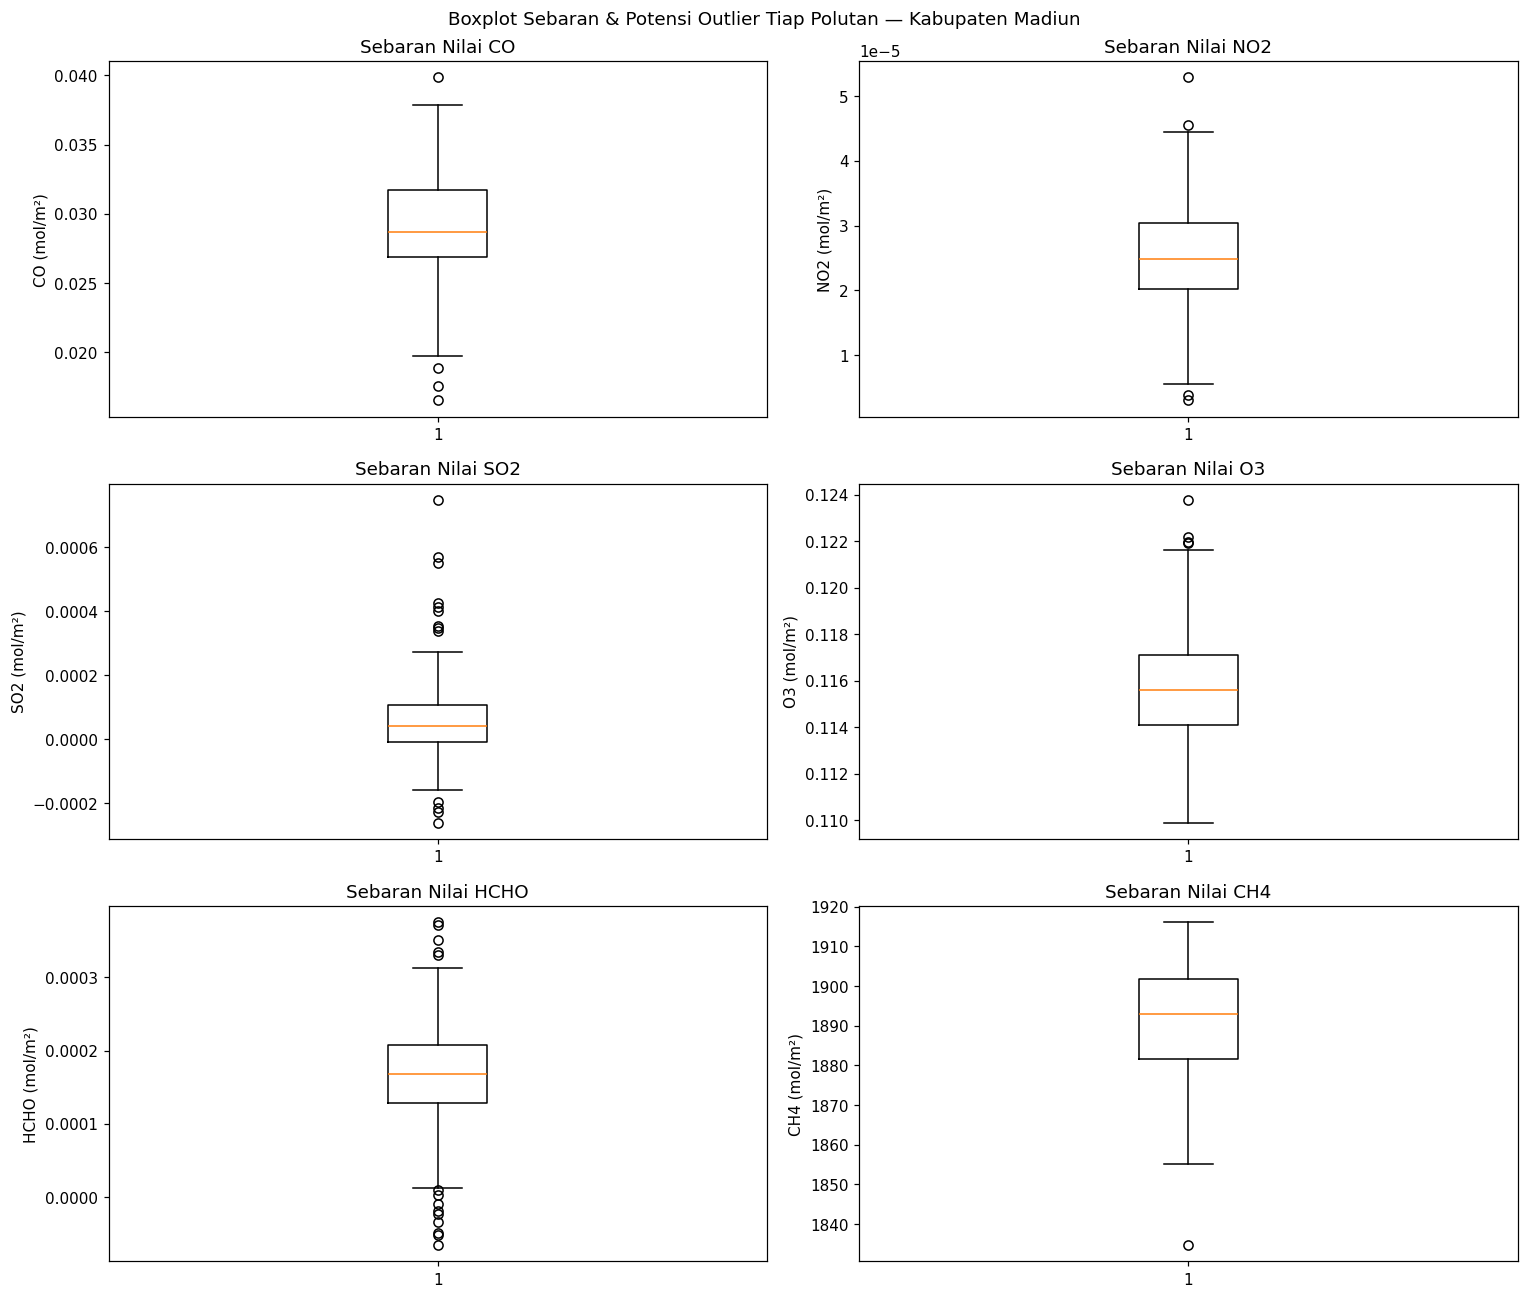

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for ax, gas in zip(axes.flatten(), daftar_polutan):
    ax.boxplot(df_polutan_madiun[gas].dropna())
    ax.set_title(f"Sebaran Nilai {gas}")
    ax.set_ylabel(f"{gas} (mol/m\u00b2)")

fig.suptitle("Boxplot Sebaran & Potensi Outlier Tiap Polutan \u2014 Kabupaten Madiun")
plt.tight_layout()
plt.show()

> Perlu dicatat bahwa nilai negatif pada data kolom Sentinel-5P (terlihat pada SO2 dan HCHO) adalah hal yang **wajar** akibat *noise* sensor, terutama pada wilayah dengan konsentrasi gas yang rendah — sehingga tidak semua outlier hasil IQR otomatis berarti kesalahan data. Beberapa titik outlier justru bisa mengindikasikan kejadian nyata, misalnya musim pembakaran jerami atau lonjakan aktivitas kawasan industri.

## 5. Visualisasi Time Series

Grafik berikut menampilkan perubahan konsentrasi tiap gas polutan di Kabupaten Madiun sepanjang periode analisa, menggunakan data harian apa adanya (belum melalui tahap pembersihan/imputasi, karena tugas ini masih dibatasi hingga tahap *Data Understanding*). Dua versi visualisasi ditampilkan: skala asli per polutan (agar mudah dibaca satuan aslinya), serta skala ternormalisasi 0–1 dalam satu grafik (agar pola pergerakan antar-gas mudah dibandingkan secara langsung).

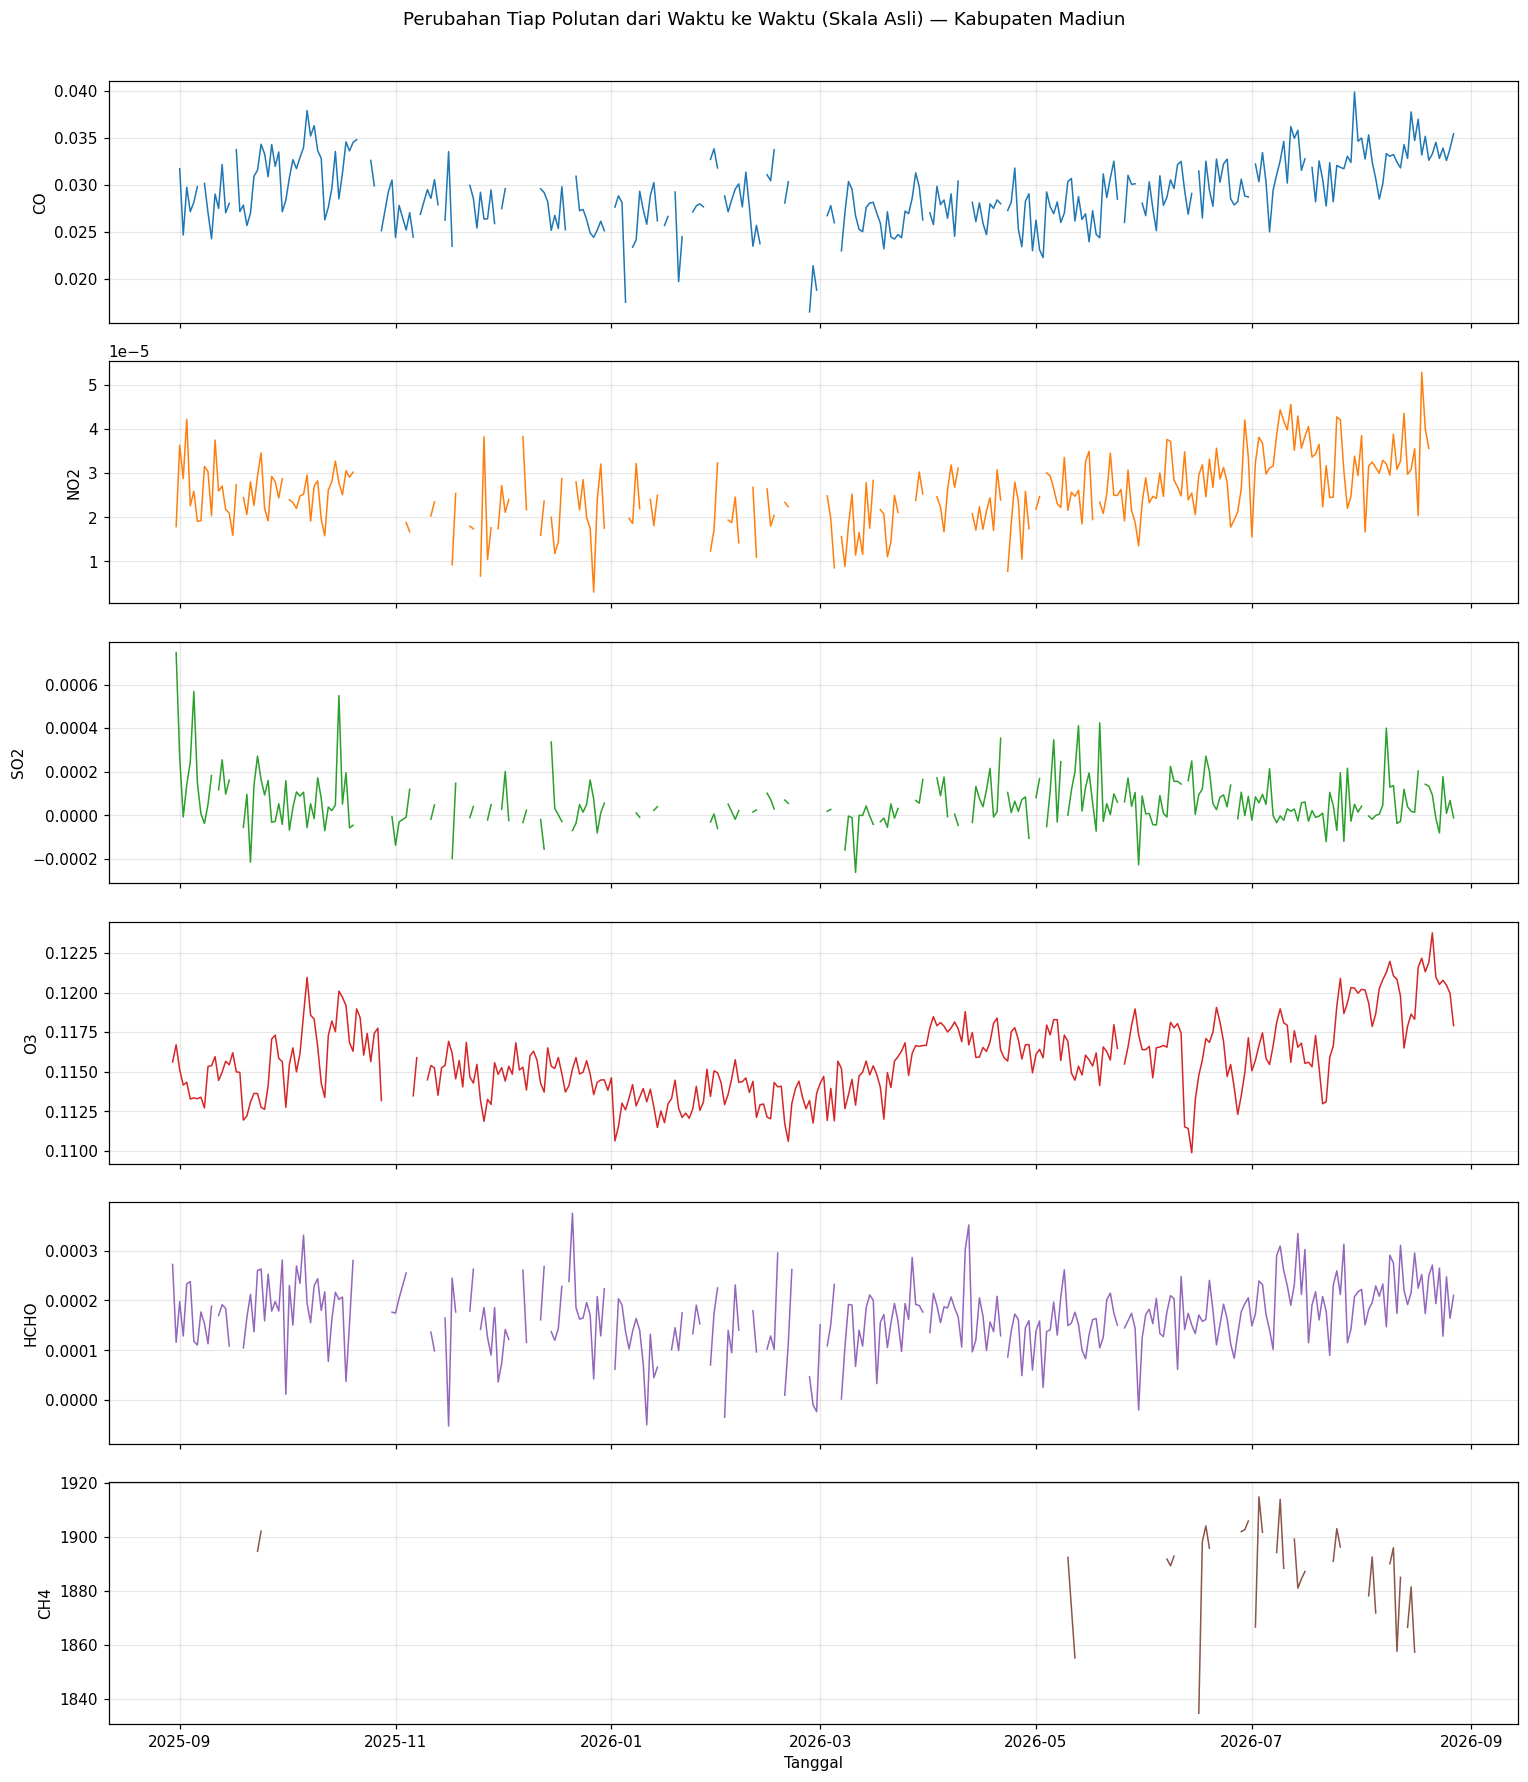

In [ ]:
fig, axes = plt.subplots(6, 1, figsize=(14, 16), sharex=True)

warna = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

for ax, gas, c in zip(axes, daftar_polutan, warna):
    ax.plot(df_polutan_madiun["tanggal"], df_polutan_madiun[gas], linewidth=1, color=c)
    ax.set_ylabel(gas)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Tanggal")
fig.suptitle("Perubahan Tiap Polutan dari Waktu ke Waktu (Skala Asli) \u2014 Kabupaten Madiun", y=1.01)
plt.tight_layout()
plt.show()

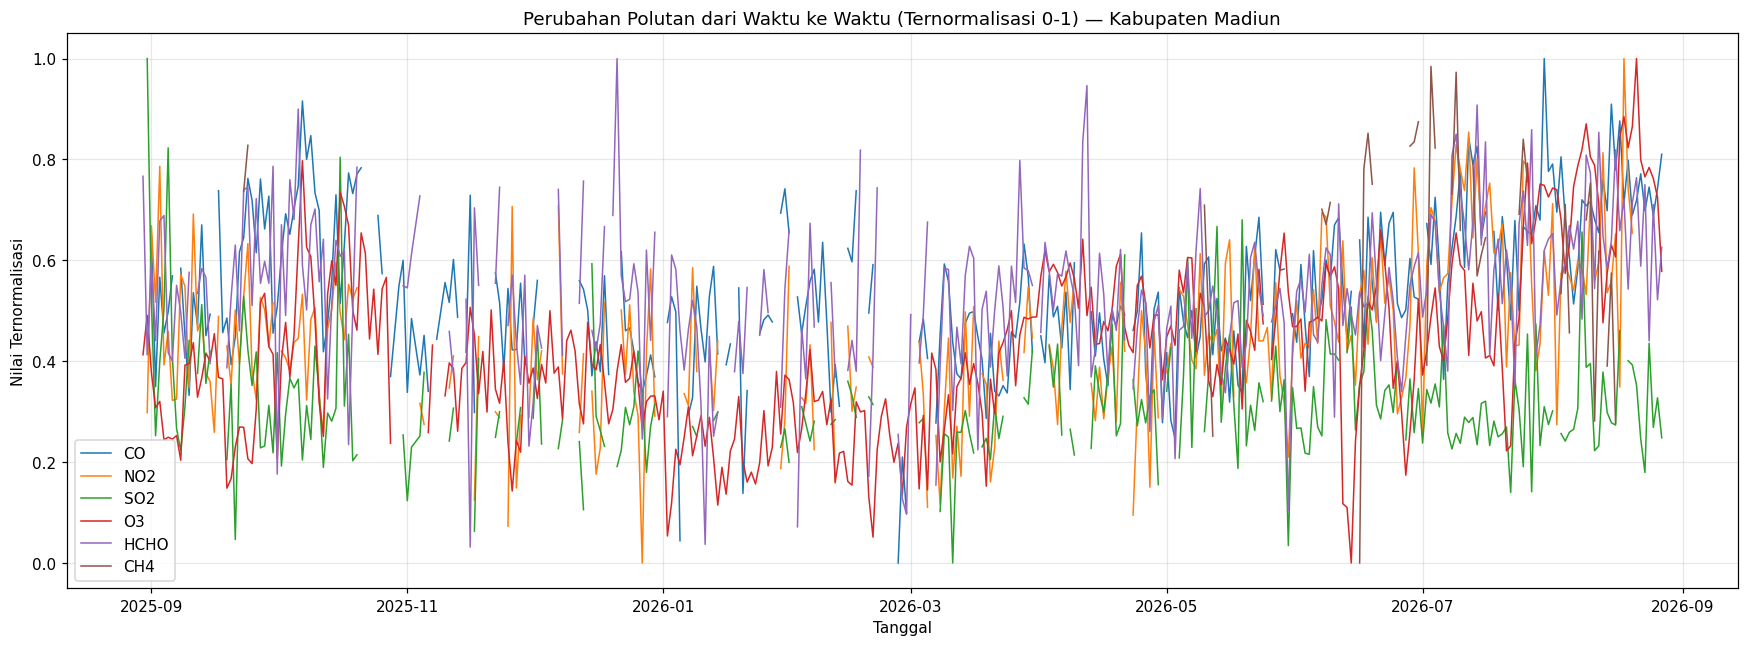

In [ ]:
df_ternormalisasi = df_polutan_madiun.copy()
for gas in daftar_polutan:
    nilai = df_ternormalisasi[gas]
    df_ternormalisasi[gas] = (nilai - nilai.min()) / (nilai.max() - nilai.min())

fig, ax = plt.subplots(figsize=(16, 6))
for gas in daftar_polutan:
    ax.plot(df_ternormalisasi["tanggal"], df_ternormalisasi[gas], linewidth=1, label=gas)

ax.set_title("Perubahan Polutan dari Waktu ke Waktu (Ternormalisasi 0-1) \u2014 Kabupaten Madiun")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Nilai Ternormalisasi")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Dari grafik skala asli terlihat **O3** dan **NO2** menunjukkan kecenderungan meningkat menjelang pertengahan tahun 2026 dibanding periode akhir 2025, yang sejalan dengan dugaan meningkatnya aktivitas kendaraan dan kawasan industri. Sementara itu **CH4** relatif fluktuatif dengan jumlah observasi paling sedikit akibat tutupan awan, dan **SO2** paling banyak bernilai mendekati nol atau negatif — konsisten dengan karakter Kabupaten Madiun yang belum memiliki sumber emisi belerang skala besar. Grafik ternormalisasi mempertegas bahwa pola pergerakan CO, NO2, O3, dan HCHO cenderung bergerak searah pada beberapa periode, mengindikasikan sumber-sumber yang berkaitan (pembakaran bahan bakar & fotokimia turunan), sedangkan SO2 relatif berada pada level ternormalisasi yang lebih rendah sepanjang tahun.

## Kesimpulan

Melalui tugas ini, data konsentrasi enam polutan udara (CO, NO2, SO2, O3, HCHO, dan CH4) di Kabupaten Madiun berhasil diperoleh dari satelit Sentinel-5P menggunakan Google Earth Engine, dengan wilayah analisa dibatasi melalui berkas GeoJSON yang digambar di [geojson.io](http://geojson.io). Karena keterbatasan satu band per permintaan pada tiap koleksi, pengambilan data dilakukan bergiliran untuk tiap gas dan hasil akhirnya digabungkan menjadi satu tabel gabungan. Tahap *data understanding* yang dilakukan mencakup pemeriksaan struktur dan isi data, deskripsi tiap fitur, identifikasi missing value (umumnya akibat tutupan awan — terutama pada CH4 yang mencapai lebih dari 85% data kosong), serta deteksi data anomali/outlier dengan metode IQR. Grafik *time series* yang dihasilkan menunjukkan pola fluktuasi tiap polutan sepanjang satu tahun pengamatan, yang diduga berkaitan dengan aktivitas pertanian (persawahan, pembakaran jerami), pertumbuhan kawasan industri di Balerejo–Pilangkenceng, aktivitas kedirgantaraan di Lanud Iswahyudi, serta lalu lintas kendaraan di jalur Solo–Madiun–Surabaya. Temuan tahap ini menjadi dasar bagi tahap pembersihan data dan pemodelan lanjutan pada pertemuan berikutnya.